Download the Federal Reserve Bank's figures on employment in the childcare industry in NYC. Answer the following questions:

In [ ]:
import pandas as pd
from google.colab import drive
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# URL of the CSV file
url = "https://raw.githubusercontent.com/robjhyndman/fpp3/refs/heads/master/data-raw/NY_ChildCare/SMU36935616562440001.csv"

# Load the data into a DataFrame
df = pd.read_csv(url, na_values=['?'])
df = df.dropna()
df.rename(columns = {"SMU36935616562440001": "Employment"}, inplace = True)
# Convert DATE to datetime and set as index
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
df.head()

,Employment
DATE,
1990-01-01,14.1
1990-02-01,14.1
1990-03-01,14.2
1990-04-01,14.0
1990-05-01,14.0


(a.) Plot the values and remark on your impressions. In particular, do you see an overall trend or any sign of seasonality? Do you see any effect from COVID?`

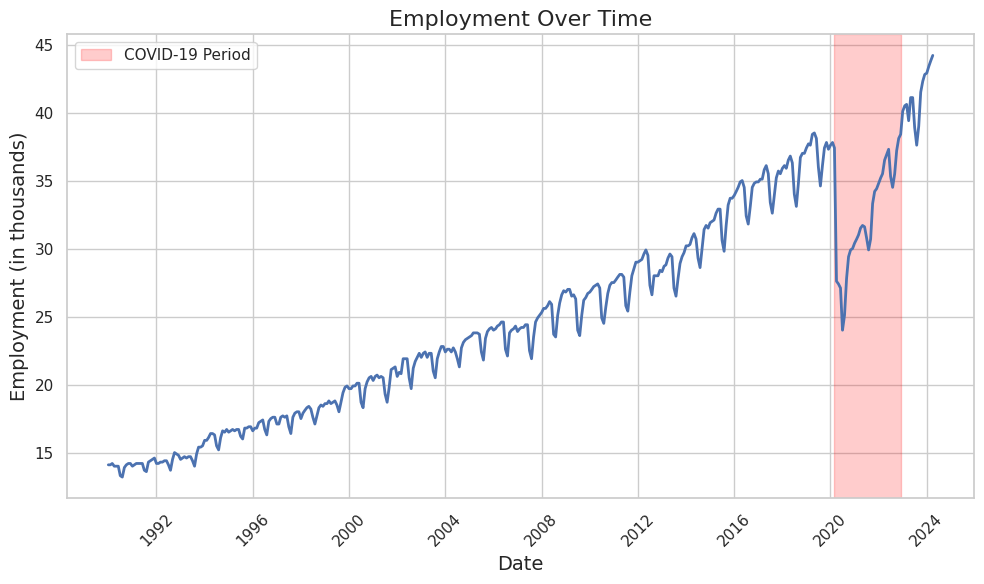

In [ ]:
# Set Seaborn style
sns.set(style="whitegrid")

# Plot with Seaborn
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x=df.index, y='Employment', linewidth=2)

# Add titles and labels
plt.title("Employment Over Time", fontsize=16)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Employment (in thousands)", fontsize=14)
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-12-01'), color='red', alpha=0.2, label='COVID-19 Period')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

The plot of employment in the childcare industry in NYC,reveals several key insights:

1. **Overall Trend**: There is a noticeable upward trend in employment over the years. This suggests growth in the childcare sector, likely due to increasing demand for childcare services.

2. **Seasonality**: The plot exhibits clear seasonal patterns, with regular fluctuations occurring within each year. These seasonal variations might be linked to school calendars or other cyclical factors affecting childcare needs.

3. **COVID-19 Impact**: A significant drop in employment is evident around early 2020, coinciding with the onset of the COVID-19 pandemic. This sharp decline reflects the widespread disruptions caused by lockdowns and social distancing measures, which likely led to temporary closures of childcare facilities and reduced demand for services.

4. **Recovery Post-COVID**: Following the initial drop, there is a gradual recovery in employment levels, indicating resilience and adaptation within the industry as restrictions eased and demand began to normalize.

Overall, the plot provides a comprehensive view of how external factors like economic growth and global events such as the COVID-19 pandemic have influenced employment trends in NYC's childcare industry.

(b.) Based on visual inspection, do you believe the time series is likely to be stationary? Use the augmented Dickey-Fuller test to verify or disprove your assumption.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(df['Employment'])

# Display results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:", adf_result[4])

# Interpretation
if adf_result[1] <= 0.05:
    print("The time series is stationary (reject the null hypothesis).")
else:
    print("The time series is not stationary (fail to reject the null hypothesis).")

ADF Statistic: 0.307253200581767
p-value: 0.9776748225226093
Critical Values: {'1%': -3.447099431978147, '5%': -2.8689225261604263, '10%': -2.57070269105012}
The time series is not stationary (fail to reject the null hypothesis).


### Visual Inspection and Augmented Dickey-Fuller Test Results
Based on visual inspection of the employment time series plot, the series appears to be non-stationary. This is evident from the clear upward trend and pronounced seasonal patterns. These characteristics suggest that the mean and variance of the series change over time, which are typical signs of non-stationarity.

**Interpretation:**

- The p-value is significantly greater than 0.05, indicating that we fail to reject the null hypothesis of the ADF test. This suggests that the time series has a unit root and is non-stationary.
- The ADF statistic is much higher than any of the critical values at the 1%, 5%, and 10% levels, further confirming non-stationarity.

**Conclusion:**

Both visual inspection and the ADF test results align in suggesting that the employment time series is non-stationary. This implies that transformations, such as differencing, may be required to achieve stationarity for further time series analysis or modeling.

(c.) Difference the time series twice, once with a difference of 12 to seasonally adjust the data, and once with a difference of 1 to remove the trend. Plot the differenced data and remark on your impressions. Use the augmented Dickey-Fuller test on the differenced data and comment on the results.

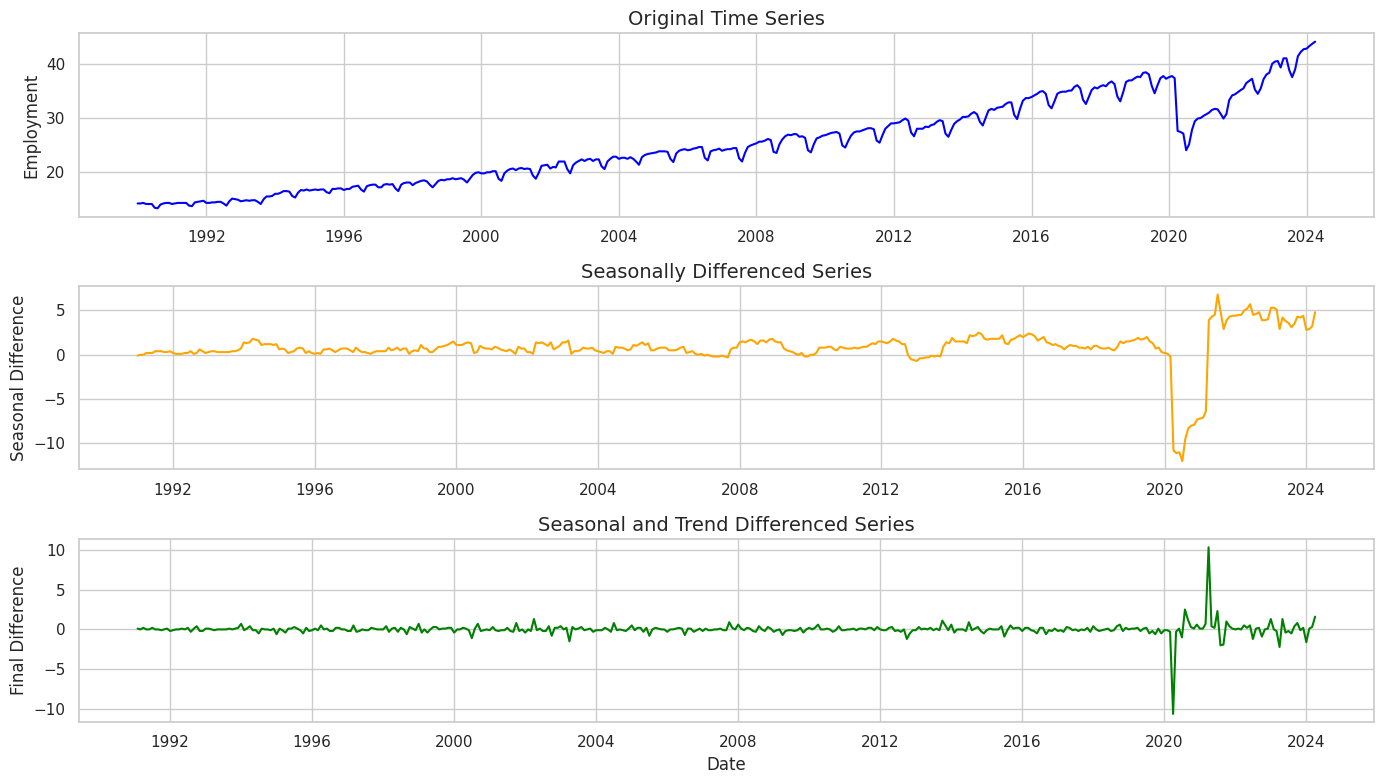

ADF Statistic (Differenced): -9.162244318246811
p-value (Differenced): 2.5147966936676514e-15
Critical Values: {'1%': -3.447360865754795, '5%': -2.8690374364690445, '10%': -2.5707639493486636}
The differenced series is stationary (reject the null hypothesis).


In [ ]:
# Seasonal differencing (lag 12)
df['Seasonally_Differenced'] = df['Employment'].diff(12)

# Trend differencing (lag 1 on seasonally differenced data)
df['Seasonal_Trend_Differenced'] = df['Seasonally_Differenced'].diff(1)

# Plot the original and differenced series
plt.figure(figsize=(14, 8))

# Plot original series
plt.subplot(3, 1, 1)
plt.plot(df.index, df['Employment'], label='Original Series', color='blue')
plt.title("Original Time Series", fontsize=14)
plt.ylabel("Employment")
plt.grid(True)

# Plot seasonally differenced series
plt.subplot(3, 1, 2)
plt.plot(df.index, df['Seasonally_Differenced'], label='Seasonally Differenced (Lag 12)', color='orange')
plt.title("Seasonally Differenced Series", fontsize=14)
plt.ylabel("Seasonal Difference")
plt.grid(True)

# Plot seasonally and trend differenced series
plt.subplot(3, 1, 3)
plt.plot(df.index, df['Seasonal_Trend_Differenced'], label='Seasonal and Trend Differenced', color='green')
plt.title("Seasonal and Trend Differenced Series", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Final Difference")
plt.grid(True)

plt.tight_layout()
plt.show()

# Perform ADF test on the twice-differenced data
result_diff = adfuller(df['Seasonal_Trend_Differenced'].dropna())
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])
print('Critical Values:', result_diff[4])

# Interpretation of Results
if result_diff[1] < 0.05:
    print("The differenced series is stationary (reject the null hypothesis).")
else:
    print("The differenced series is not stationary (fail to reject the null hypothesis).")


### Analysis of Differenced Data and ADF Test Results

**Visual Inspection:**

Upon examining the plot of the differenced data, we observe that:

- **Mean and Variance**: The mean and variance appear relatively constant throughout the series, indicating stationarity. This suggests that the differencing has successfully removed trends and seasonal effects, stabilizing the time series.
- **COVID-19 Impact**: There may still be some irregularities or spikes during the COVID-19 period, reflecting the significant disruptions during that time.

**Augmented Dickey-Fuller Test Results:**

- **ADF Statistic**: The test statistic is $$-9.162$$, which is significantly lower (more negative) than all critical values at the 1%, 5%, and 10% significance levels. This indicates strong evidence against the null hypothesis.
- **p-value**: The p-value is $$2.5148 \times 10^{-15}$$, which is extremely small and far below typical significance thresholds such as 0.05 or 0.01.

**Conclusion:**

Given these results, we can confidently reject the null hypothesis that the series is non-stationary. The strong evidence provided by both the ADF statistic and the p-value confirms that the differenced series is stationary. This transformation allows for more reliable modeling and forecasting using statistical methods that assume stationarity, such as ARIMA models.

The stationarity achieved through differencing indicates that any further analysis or model fitting can proceed without concerns over non-stationary data skewing results or predictions.


(d.) Plot both the autocorrelation and partial autocorrelation of the differenced data for three years (36 months) of lags. Do you see any significant correlations? If so, are they positive or negative? What lags are significantly correlated?

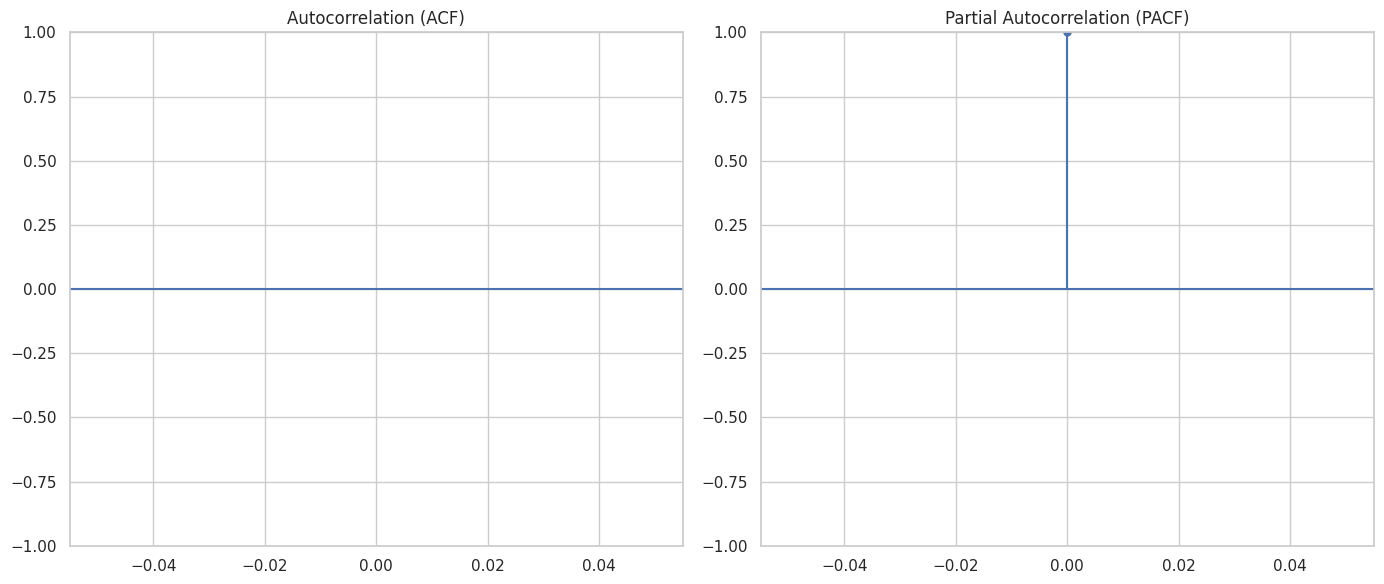

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for up to 36 lags (three years for monthly data)
plt.figure(figsize=(14, 6))

# Autocorrelation plot
plt.subplot(1, 2, 1)
plot_acf(df['Seasonal_Trend_Differenced'], lags=36, ax=plt.gca(), title="Autocorrelation (ACF)")

# Partial Autocorrelation plot
plt.subplot(1, 2, 2)
plot_pacf(df['Seasonal_Trend_Differenced'], lags=36, ax=plt.gca(), title="Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

### Autocorrelation and Partial Autocorrelation Analysis

**Autocorrelation Function (ACF):**
- There are no visible significant spikes in the ACF plot beyond the confidence interval. This suggests no significant autocorrelations at any lag.

**Partial Autocorrelation Function (PACF):**
- There is a single significant spike at lag 0, indicating that only the immediate observation is strongly correlated with itself, which is expected.

These observations suggest that the differenced series behaves like white noise, with no significant patterns remaining.

(E) - Apply STL decomposition to the original data using period=12. Plot the results, and remark on them. Are they consistent with your impressions from step a?

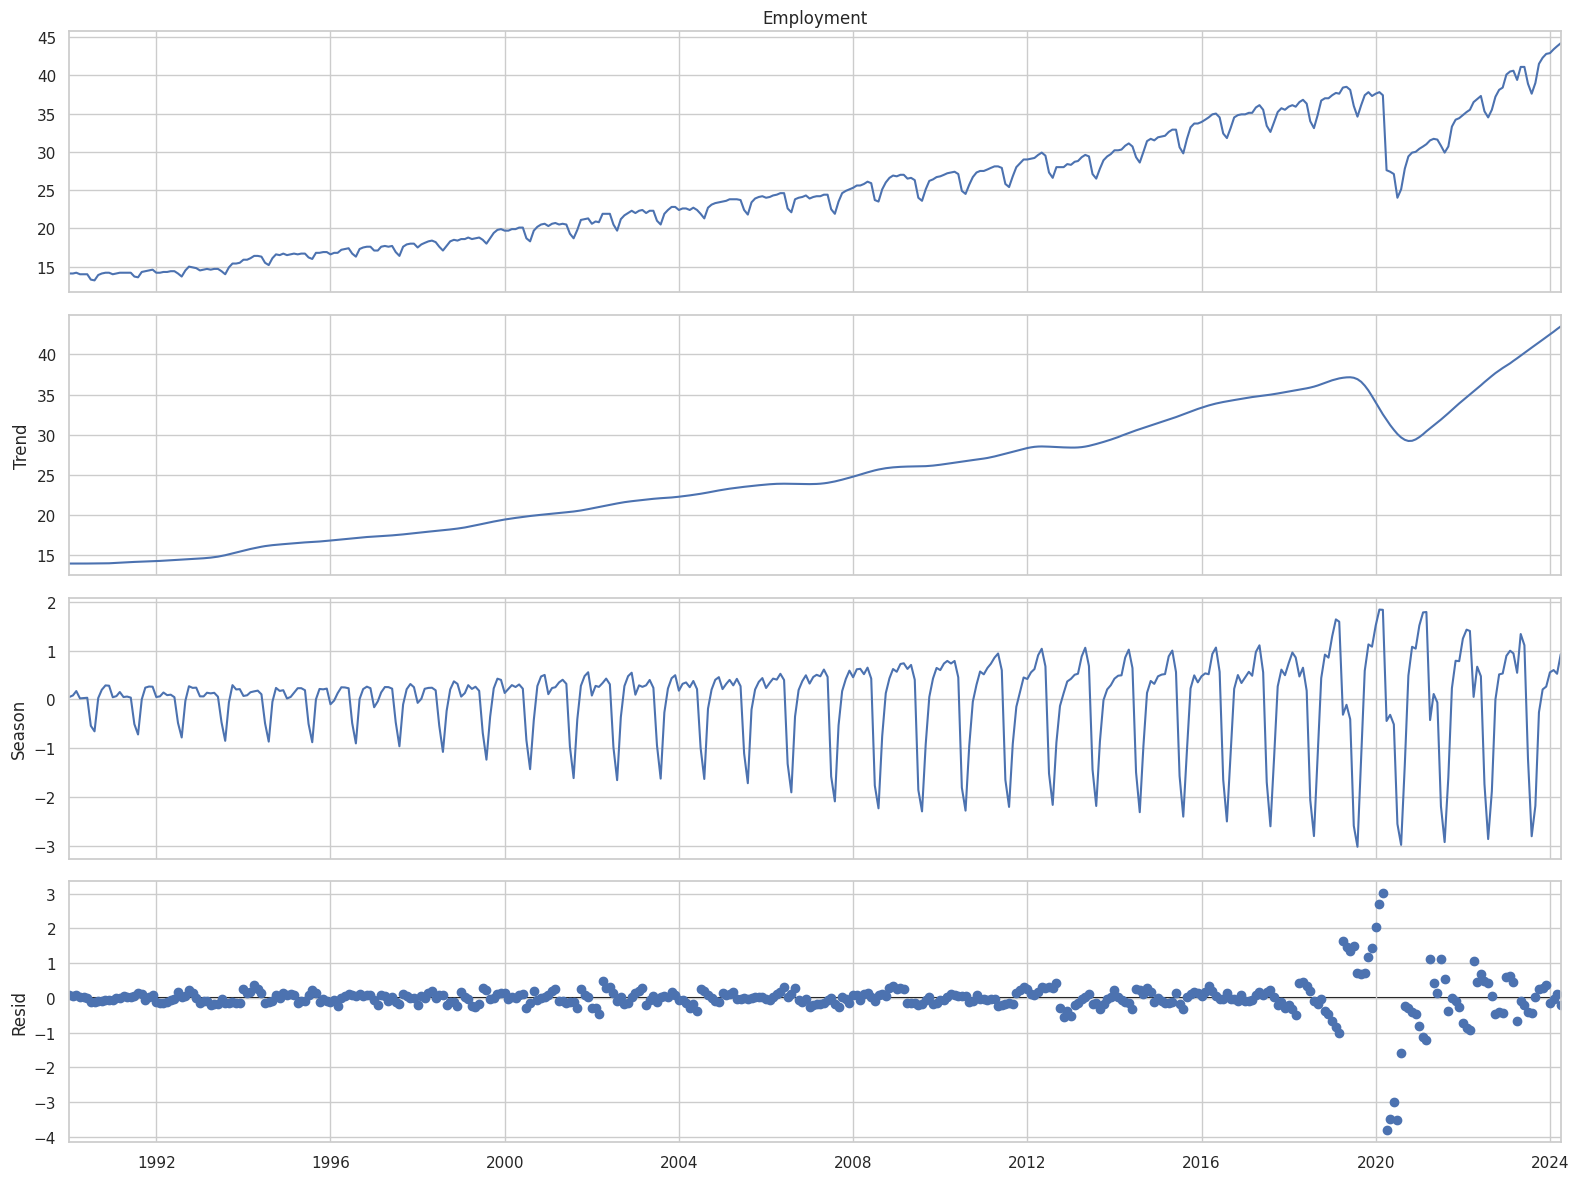

In [9]:
from statsmodels.tsa.seasonal import STL
# Apply STL decomposition
stl = STL(df['Employment'], period=12)
res = stl.fit()

# Plot the STL decomposition results
plt.rc("figure", figsize=(16, 12))
plt.rc("font", size=13)
fig = res.plot()
plt.show()

### Remarks on STL Decomposition

**Trend Component:**
- The trend shows a clear upward trajectory over time, consistent with the initial observation of growth in employment.

**Seasonal Component:**
- The seasonal component reveals regular, repeating patterns, confirming the presence of seasonality noted earlier.

**Residual Component:**
- The residuals appear mostly random, with some irregularities around the COVID-19 period, indicating that most patterns have been captured by the trend and seasonal components.

### Consistency with Initial Impressions

The STL decomposition aligns well with initial impressions from step a:
- **Trend and Seasonality**: Both were clearly identified in the original analysis and are effectively captured by the STL components.
- **COVID-19 Impact**: The residuals highlight disruptions during the pandemic, consistent with observed data anomalies during that period.

Overall, the decomposition confirms and clarifies initial observations about trends and seasonality in the data.